# On the fly augmentation

## #1: Install & Import

In [1]:
# Install if needed
# !pip install albumentations datasets torch pillow matplotlib numpy python-dotenv

import os
from dotenv import load_dotenv
load_dotenv()  # charge les variables depuis .env (ex: HF_TOKEN)

import albumentations as A
from albumentations.pytorch import ToTensorV2
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import random

print("Libraries imported successfully!")

Libraries imported successfully!


## #2: Define medical-safe augmentation pipeline

Watch out not every methods are safe for our use case
https://www.sciencedirect.com/science/article/pii/S277244252400042X#tbl7

In [2]:
train_transform = A.Compose([
    # Resize to fixed size
    A.Resize(224, 224),

    # Geometric transformations
    A.Rotate(
        limit=10,  # Max 10°
        border_mode=cv2.BORDER_CONSTANT,
        p=0.7
    ),

    A.ShiftScaleRotate(
        shift_limit=0.1,       # +10% translation
        scale_limit=0.1,       # 90-110% zoom
        rotate_limit=0,
        p=0.7,
        border_mode=cv2.BORDER_CONSTANT,
    ),

    # Horizontal flip only (lungs are symmetric)
    A.HorizontalFlip(p=0.5),

    # Elastic deformation
    A.ElasticTransform(
        alpha=1,
        sigma=50,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.2
    ),

    # Perspective & distortion
    A.OneOf([
        A.GridDistortion(
            num_steps=5,
            distort_limit=0.2,
            border_mode=cv2.BORDER_CONSTANT,
            p=1.0
        ),
        A.OpticalDistortion(
            distort_limit=0.3,
            border_mode=cv2.BORDER_CONSTANT,
            p=1.0
        ),
    ], p=0.3),

    # Intensity modifications
    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=1.0
        ),
        A.RandomGamma(gamma_limit=(80, 120), p=1.0),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
    ], p=0.9),

    # Blur & sharpening
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0),
    ], p=0.4),

    # Noise
    A.OneOf([
        A.GaussNoise(p=1.0),
        A.ISONoise(
            color_shift=(0.01, 0.03),
            intensity=(0.05, 0.3),
            p=1.0
        ),
        A.MultiplicativeNoise(
            multiplier=(0.95, 1.05),
            per_channel=True,
            p=1.0
        ),
    ], p=0.3),

    # Normalize & convert to tensor
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
# Validation/Test
val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("\nAugmentation pipelines created!\n")


Augmentation pipelines created!



/media/DATA/Projects/bellinna/Zoidberg2.0/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## #3: Load dataset

In [3]:
# Load dataset from HuggingFace (token lu depuis .env : HF_TOKEN)
print("Loading dataset...")
hf_token = os.getenv("KEY_HUGGING_FACE")
dataset = load_dataset("PAR8/chest-xray-pneumonia", token=hf_token)

print(f"\n  Dataset loaded!")
print(f"  Train: {len(dataset['train'])} images")
print(f"  Validation: {len(dataset['validation'])} images")
print(f"  Test: {len(dataset['test'])} images")


Loading dataset...


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00010.parquet:   0%|          | 0.00/311M [00:00<?, ?B/s]

train-00001-of-00010.parquet:   0%|          | 0.00/332M [00:00<?, ?B/s]

train-00002-of-00010.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

...

test-00001-of-00002.parquet:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4705 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/522 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]


  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images


## #4: Apply transforms to dataset

In [12]:
# Transform functions

# Apply augmentation to training images
def apply_train_transforms(examples):
    images = []
    for img in examples['image']:
        # Convert PIL image to numpy array
        img_array = np.array(img.convert('RGB'))
        # Apply transforms
        transformed = train_transform(image=img_array)
        images.append(transformed['image'])

    return {'image': images, 'label': examples['label']}

# Apply only normalization
def apply_val_test_transforms(examples):
    images = []
    for img in examples['image']:
        # Convert PIL image to numpy array
        img_array = np.array(img.convert('RGB'))
        # Apply transforms
        transformed = val_test_transform(image=img_array)
        images.append(transformed['image'])

    return {'image': images, 'label': examples['label']}

# Apply to datasets
train_data = dataset['train'].with_transform(apply_train_transforms)
val_data = dataset['validation'].with_transform(apply_val_test_transforms)
test_data = dataset['test'].with_transform(apply_val_test_transforms)

print("\n Transforms applied!")
print(" Images will be augmented on-the-fly when you load them")

NameError: name 'dataset' is not defined

## #5: Visualize augmentation

In [13]:
# Denormalize for visualization
def denormalize(tensor):
    import torch
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get original image
sample_idx = random.randint(1, 10)
original_img = dataset['train'][sample_idx]['image']
label = dataset['train'][sample_idx]['label']
label_names = {0: "NORMAL", 1: "BACTERIA", 2: "VIRUS"}

# Create visualization
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Original
axes[0].imshow(original_img)
axes[0].set_title('ORIGINAL', fontsize=14, fontweight='bold', color='green')
axes[0].axis('off')

# 8 augmented versions
for i in range(8):
    aug_img = train_data[sample_idx]['image']
    aug_img_display = denormalize(aug_img).permute(1, 2, 0).numpy()
    aug_img_display = np.clip(aug_img_display, 0, 1)

    axes[i+1].imshow(aug_img_display)
    axes[i+1].set_title(f'#{i+1}', fontsize=15)
    axes[i+1].axis('off')

plt.suptitle(f'IMG NUMBER {sample_idx} ({label_names[label]})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'dataset' is not defined

## #6: Create DataLoaders

In [ ]:
import torch
from torch.utils.data import DataLoader

# Configuration
BATCH_SIZE = 64
NUM_WORKERS = 8

# Create DataLoaders
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

print("\n  DataLoaders ready!")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

## #7: Example - Load a batch

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [2, 0, 1, 2, 0, 0, 1, 2, 2, 2]
Label distribution: [9, 15, 8]


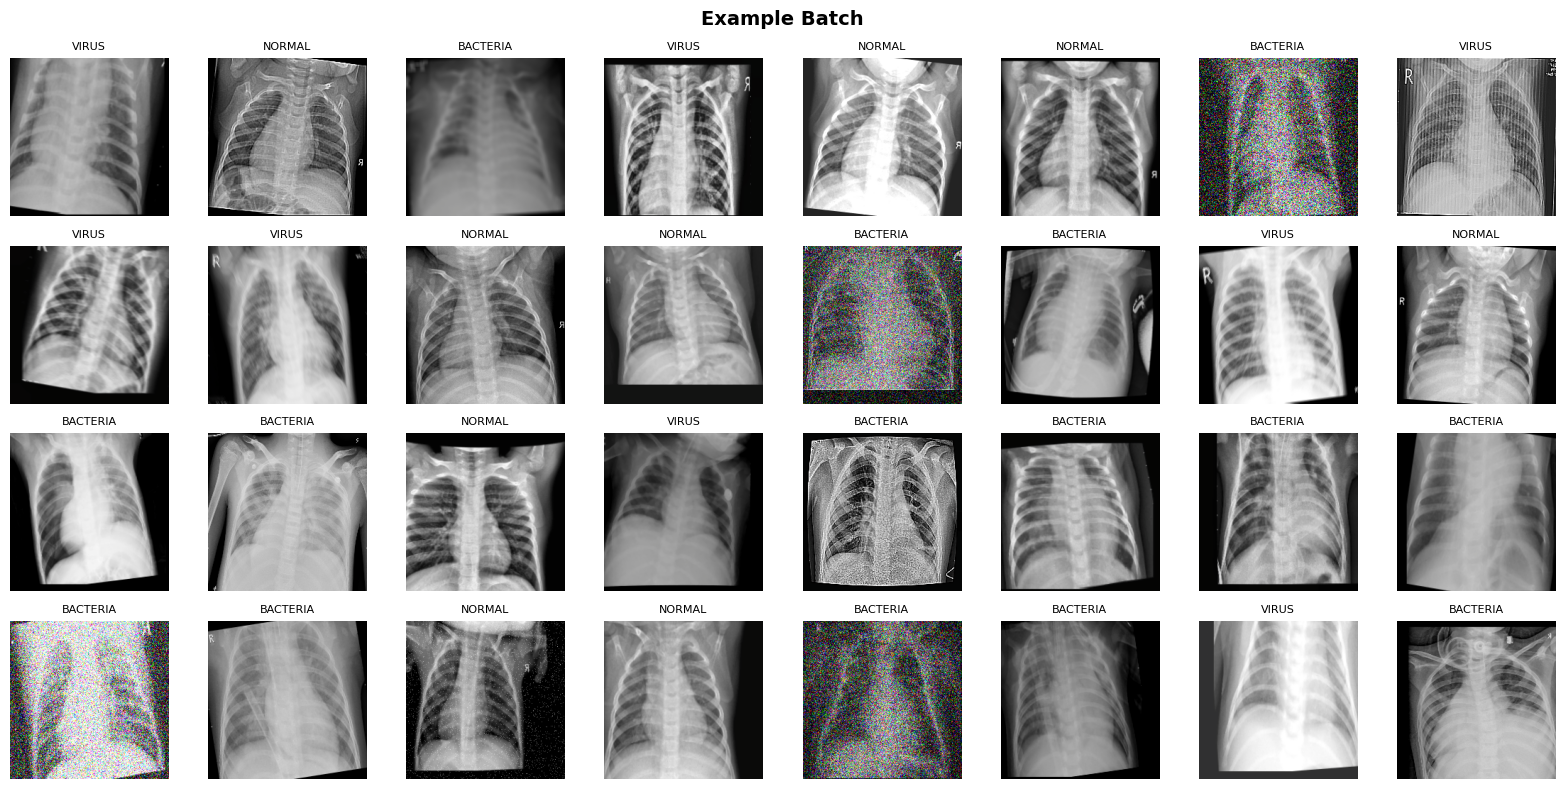

In [ ]:
# Get one batch
batch = next(iter(train_loader))
images = batch['image']  # Augmented images as tensors
labels = batch['label']  # Labels

print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nFirst 10 labels: {labels[:10].tolist()}")
print(f"Label distribution: {torch.bincount(labels).tolist()}")

# Visualize batch
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(32, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(f'{label_names[labels[i].item()]}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Example Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()